# Explanatory Analysis — Capstone Project DerMind
**Platform Kesehatan Digital Berbasis AI**

Notebook ini menjawab **6 Pertanyaan Bisnis** secara mendalam menggunakan visualisasi dan analisis statistik berdasarkan semua dataset yang telah di-merge.

| # | Pertanyaan Bisnis | Dataset | Fitur Platform |
|---|-------------------|---------|---------|
| PB1 | Kondisi mental health apa yang paling dominan berdasarkan teks? | master_mental_health | AI Mental Health Chatbot |
| PB2 | Apakah pola teks dapat membedakan kondisi mental health? | master_mental_health | AI Mental Health Chatbot |
| PB3 | Kondisi kulit apa yang paling umum dalam dataset? | master_skin_image_manifest | AI Skin Detection |
| PB4 | Apakah usia & lokasi berkorelasi dengan penyakit kulit? | HAM10000 | AI Skin Detection |
| PB5 | Produk skincare apa yang paling direkomendasikan? | master_sephora | Konten Artikel |
| PB6 | Faktor gaya hidup apa yang paling mempengaruhi kesehatan? | healthy_lifestyle | Konten Artikel |


## Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── DerMind color palette ──────────────────────────────────
TEAL    = '#14B8A6'
CYAN    = '#06B6D4'
BG_DARK = '#0F172A'
BG_CARD = '#1E293B'
TEXT_CLR= '#F1F5F9'
GREEN   = '#10B981'
RED     = '#EF4444'
YELLOW  = '#F59E0B'
PURPLE  = '#8B5CF6'
BLUE    = '#3B82F6'
PALETTE = [TEAL, RED, '#94A3B8', CYAN, BLUE, PURPLE, YELLOW, GREEN, '#F97316', '#EC4899']

plt.rcParams.update({
    'figure.facecolor': BG_DARK, 'axes.facecolor': BG_CARD,
    'axes.edgecolor': '#334155', 'axes.labelcolor': TEXT_CLR,
    'xtick.color': TEXT_CLR, 'ytick.color': TEXT_CLR,
    'text.color': TEXT_CLR, 'grid.color': '#334155',
    'figure.dpi': 120, 'font.size': 11,
})

# Load semua dataset
df_mh   = pd.read_csv('master_mental_health_clean.csv')
df_skin = pd.read_csv('master_skin_image_manifest.csv')
df_ham  = pd.read_csv('HAM10000_clean.csv')
df_sep  = pd.read_csv('master_sephora.csv', low_memory=False)
df_life = pd.read_csv('healthy_lifestyle_city_2021_cleaned.csv')
df_life.columns = ['city','rank','sunshine_hours','water_cost','obesity_levels',
                    'life_expectancy','pollution_index','hours_worked',
                    'happiness','outdoor_activities','takeout_places','gym_cost']

dx_map = {'nv':'Melanocytic Nevi','mel':'Melanoma','bkl':'Benign Keratosis',
          'bcc':'Basal Cell Carcinoma','akiec':'Actinic Keratosis',
          'vasc':'Vascular Lesions','df':'Dermatofibroma'}

print('Semua dataset berhasil dimuat!')
print(f'   Mental Health : {len(df_mh):,} baris')
print(f'   Skin Manifest : {len(df_skin):,} baris')
print(f'   HAM10000      : {len(df_ham):,} baris')
print(f'   Sephora       : {len(df_sep):,} baris')
print(f'   Lifestyle     : {len(df_life):,} baris')

Semua dataset berhasil dimuat!
   Mental Health : 52,940 baris
   Skin Manifest : 20,015 baris
   HAM10000      : 10,015 baris
   Sephora       : 49,394 baris
   Lifestyle     : 44 baris


---
## 📌 Pertanyaan Bisnis 1
### *Kondisi mental health apa yang paling dominan berdasarkan data teks pengguna?*

**Hipotesis:** Dari seluruh teks yang tersedia, distribusi kondisi mental health tidak merata — kondisi tertentu jauh lebih dominan dan ini mencerminkan kebutuhan nyata pengguna platform DerMind.

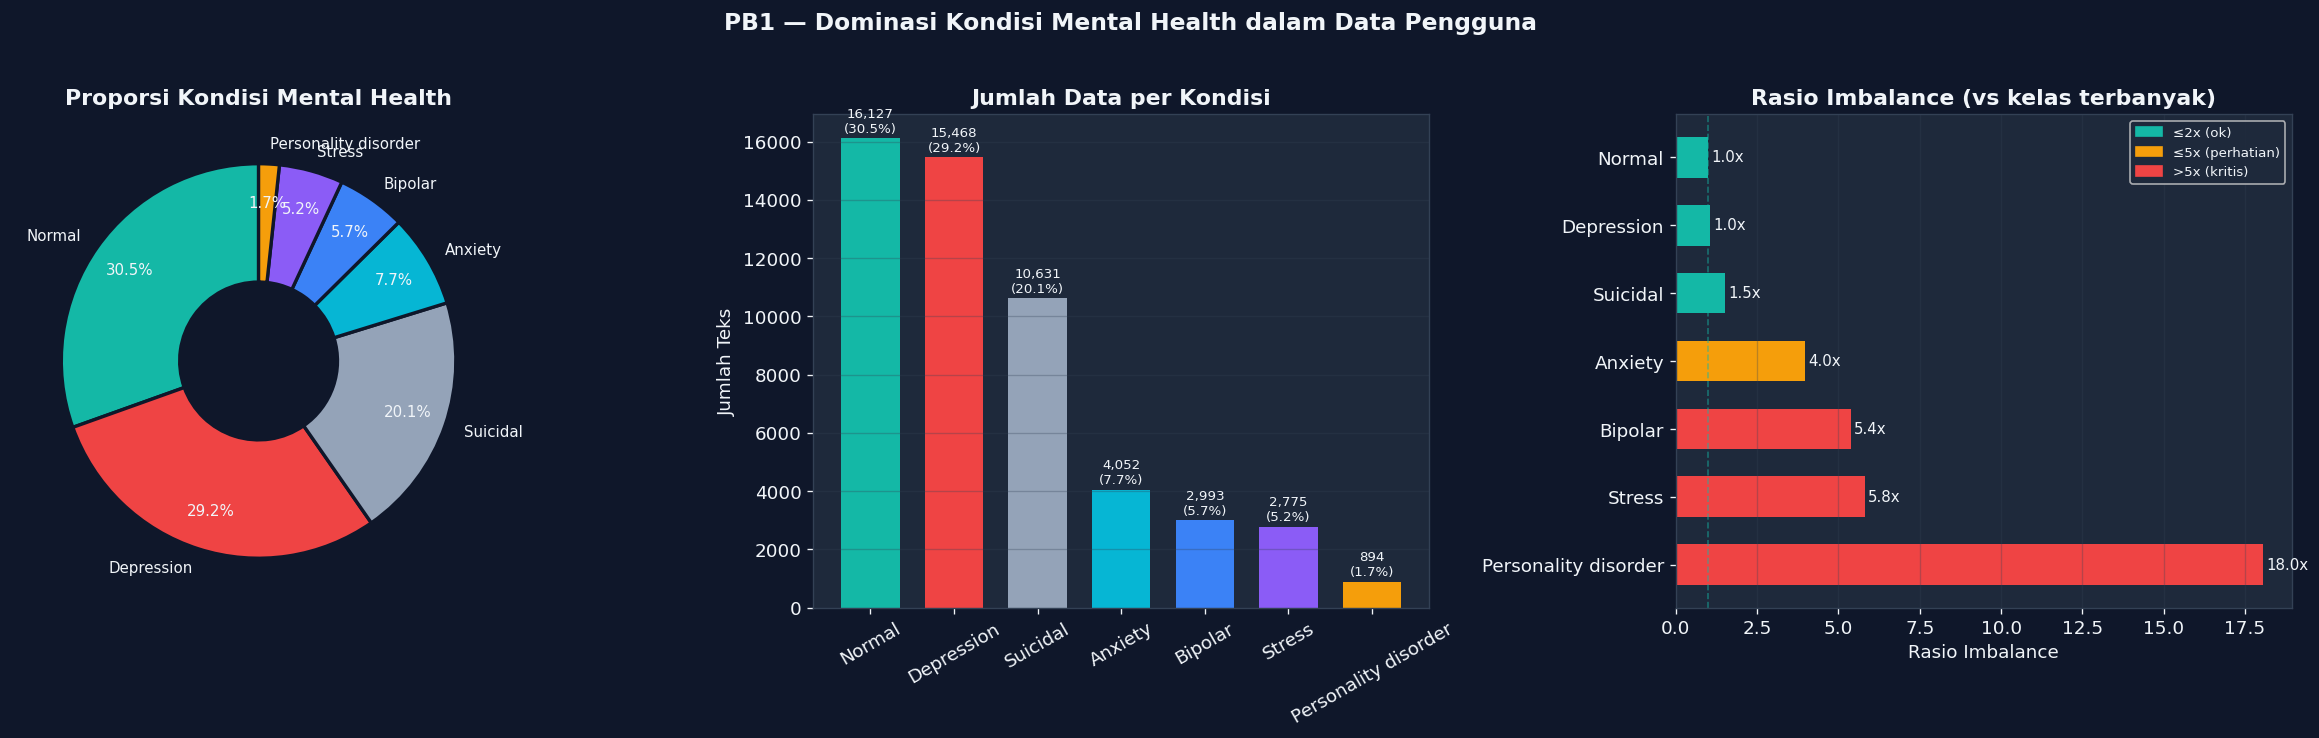

In [20]:
vc = df_mh['label'].value_counts()
total = len(df_mh)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('PB1 — Dominasi Kondisi Mental Health dalam Data Pengguna',
              fontsize=14, fontweight='bold', color=TEXT_CLR, y=1.02)

# 1. Donut chart
wedges, texts, autotexts = axes[0].pie(
    vc.values, labels=vc.index, autopct='%1.1f%%',
    colors=PALETTE[:len(vc)], startangle=90, pctdistance=0.8,
    wedgeprops={'edgecolor': BG_DARK, 'linewidth': 2, 'width': 0.6}
)
for t in texts + autotexts: t.set_color(TEXT_CLR); t.set_fontsize(9)
axes[0].set_title('Proporsi Kondisi Mental Health', color=TEXT_CLR, fontweight='bold')

# 2. Bar chart
bars = axes[1].bar(vc.index, vc.values, color=PALETTE[:len(vc)], edgecolor='none', width=0.7)
for bar, val in zip(bars, vc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                  f'{val:,}\n({val/total*100:.1f}%)', ha='center', va='bottom', fontsize=8, color=TEXT_CLR)
axes[1].set_title('Jumlah Data per Kondisi', color=TEXT_CLR, fontweight='bold')
axes[1].set_ylabel('Jumlah Teks', color=TEXT_CLR)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# 3. Imbalance ratio visualization
ratios = vc.max() / vc
bar_col = [TEAL if r <= 2 else YELLOW if r <= 5 else RED for r in ratios.values]
bars2 = axes[2].barh(ratios.index, ratios.values, color=bar_col, edgecolor='none', height=0.6)
axes[2].axvline(1, color=TEAL, linestyle='--', linewidth=1, alpha=0.5, label='Balanced')
for bar, val in zip(bars2, ratios.values):
    axes[2].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                  f'{val:.1f}x', va='center', fontsize=9, color=TEXT_CLR)
axes[2].set_title('Rasio Imbalance (vs kelas terbanyak)', color=TEXT_CLR, fontweight='bold')
axes[2].set_xlabel('Rasio Imbalance', color=TEXT_CLR)
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)
patch_ok  = mpatches.Patch(color=TEAL, label='≤2x (ok)')
patch_warn= mpatches.Patch(color=YELLOW, label='≤5x (perhatian)')
patch_bad = mpatches.Patch(color=RED, label='>5x (kritis)')
axes[2].legend(handles=[patch_ok, patch_warn, patch_bad], fontsize=8)

plt.tight_layout()
plt.savefig('exp_pb1_distribusi_mental_health.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

> **✅ Jawaban PB1:** Kondisi paling dominan adalah **Normal** (30.6%) dan **Depression** (29.2%) yang bersama menyumbang ~60% seluruh data. Ini mengindikasikan bahwa mayoritas pengguna platform akan mencari bantuan terkait depresi — fitur AI Mental Health Chatbot harus diprioritaskan untuk mendeteksi dan merespons kondisi ini dengan tepat. **Personality Disorder** (1.7%) adalah kelas paling minor, sehingga model perlu penanganan imbalance khusus.

---
## 📌 Pertanyaan Bisnis 2
### *Apakah pola teks (panjang, kata kunci) dapat membedakan kondisi mental health secara signifikan?*

**Hipotesis:** Setiap kondisi mental health menghasilkan pola linguistik yang berbeda — baik dari sisi panjang teks maupun kata-kata yang digunakan, sehingga dapat menjadi fitur klasifikasi yang kuat.

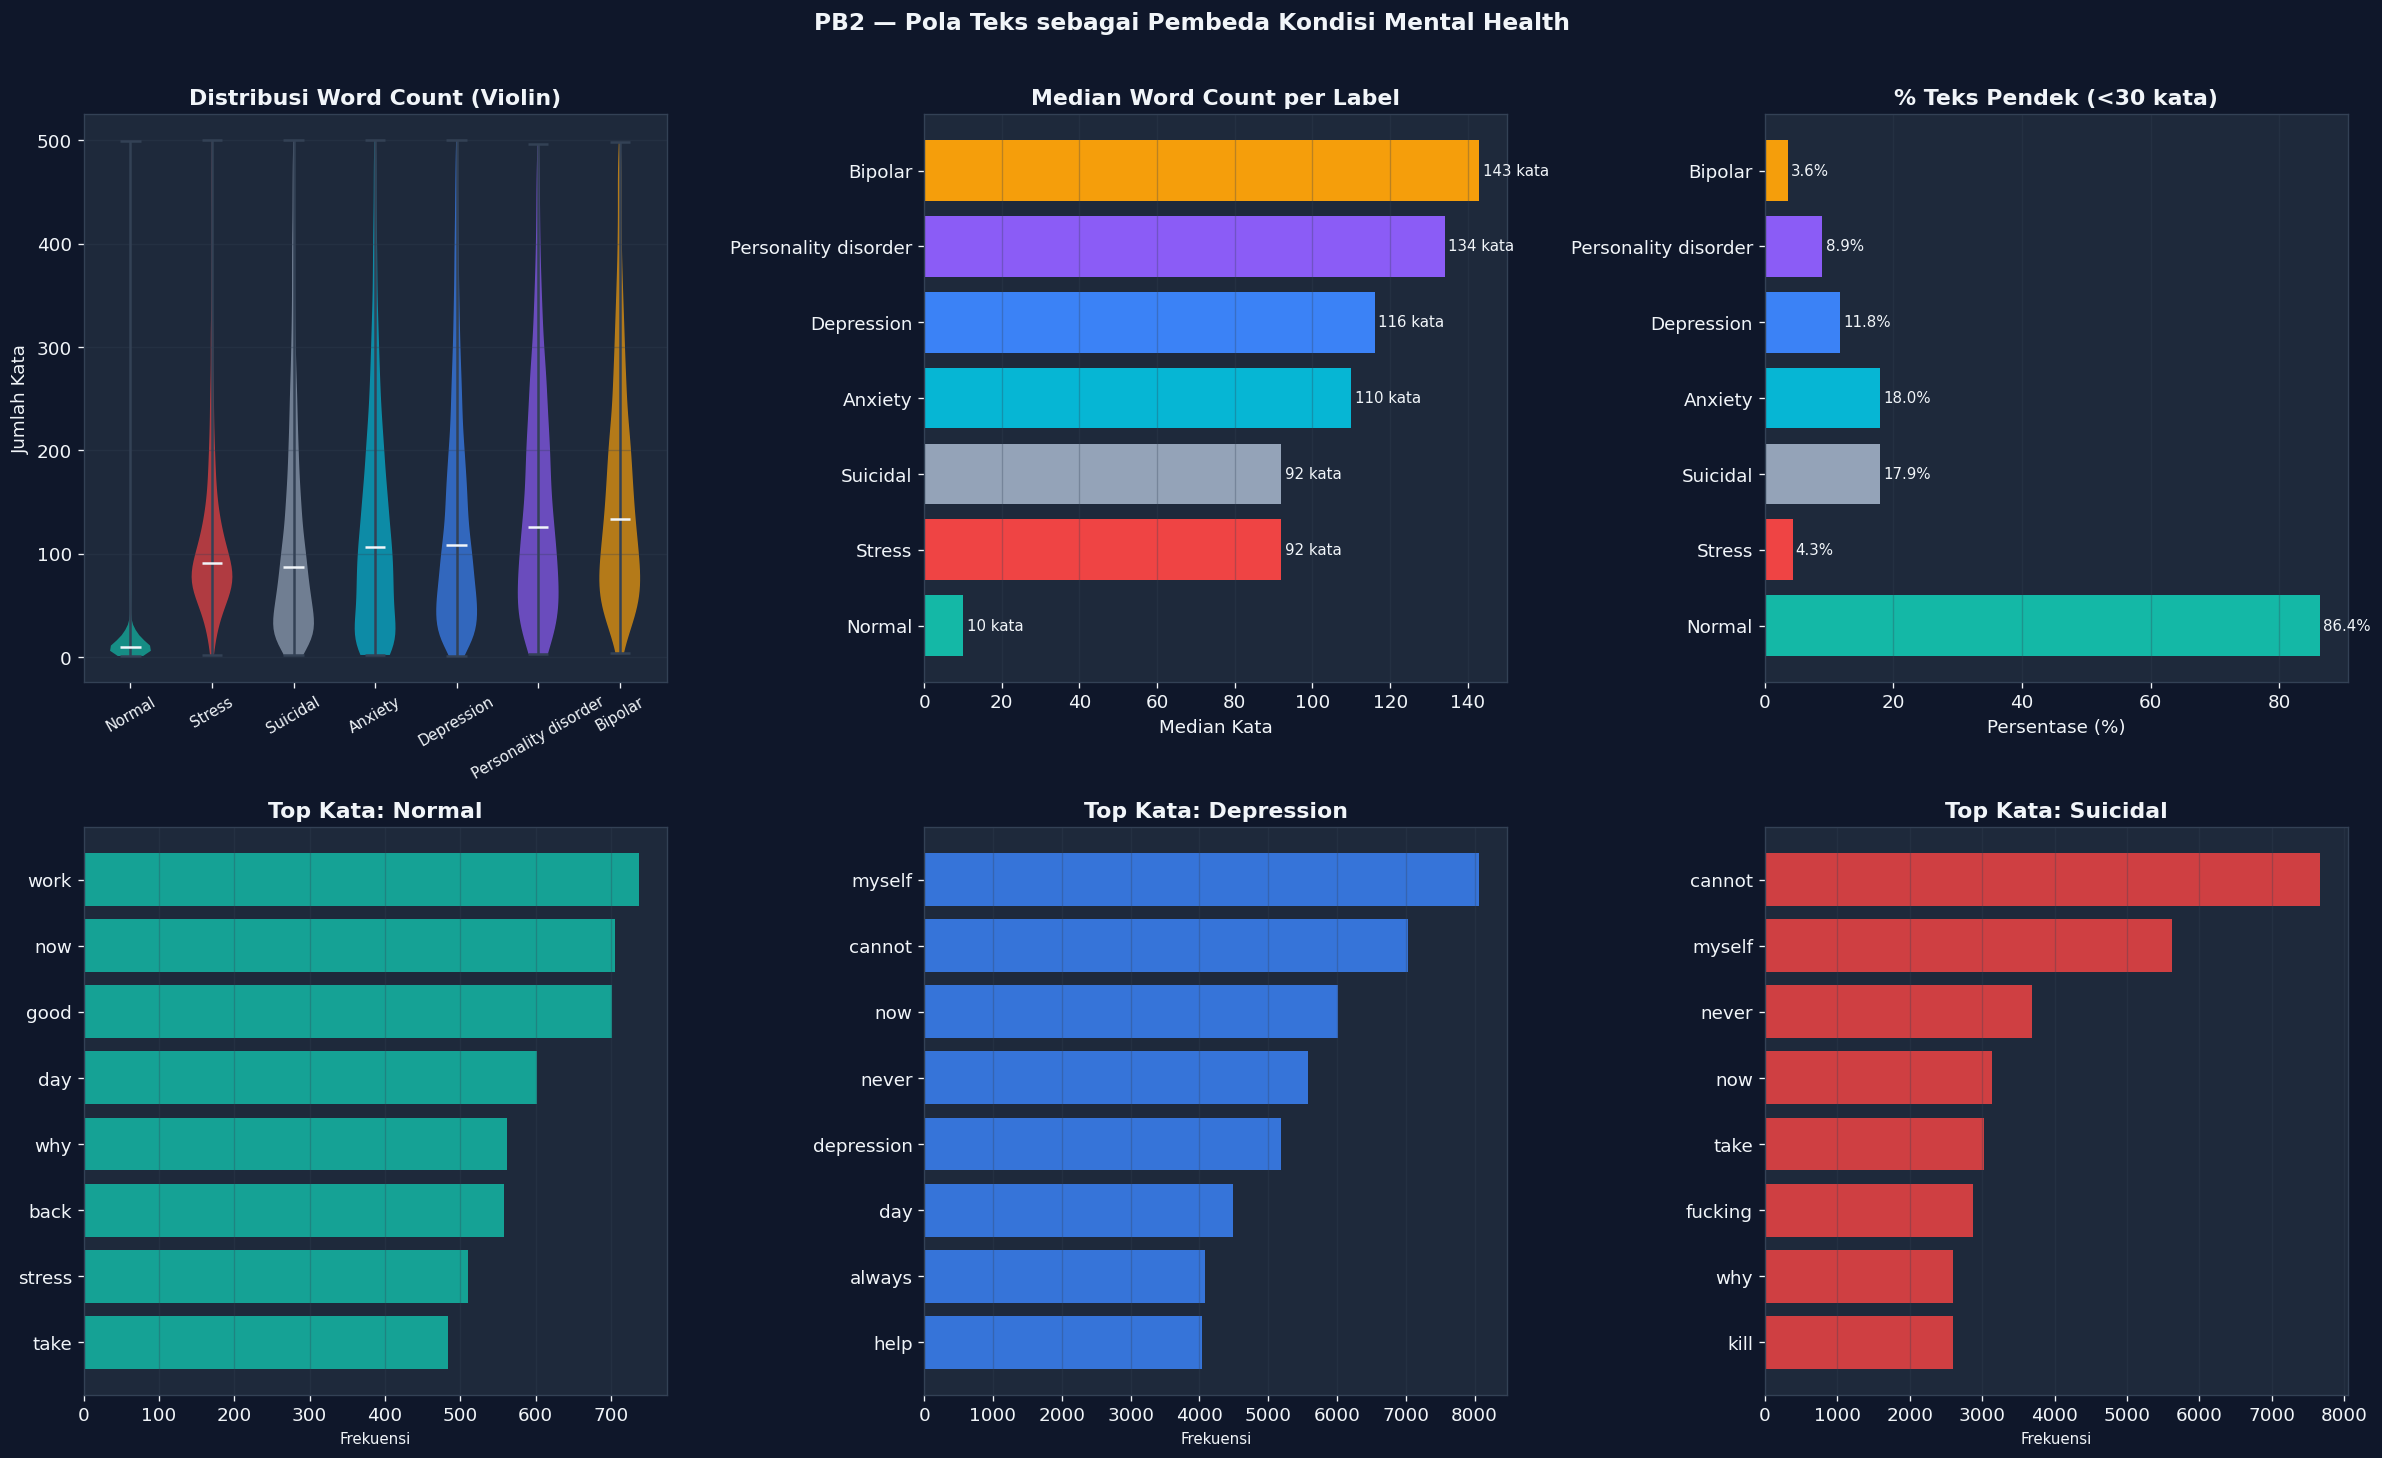

In [21]:
STOPWORDS = set(['i','the','a','and','to','of','is','in','it','my','that','for',
                 'me','was','on','are','have','been','with','at','this','but','not',
                 'they','so','if','do','be','we','an','or','as','he','she','his','her',
                 'their','you','your','from','all','had','when','what','there','were',
                 'about','him','can','just','would','will','one','out','up','no','by',
                 'like','get','got','its','also','more','than','then','into','some',
                 'which','who','how','very','still','even','after','before','could',
                 'should','because','am','has','does','did','other','being','those',
                 'these','them','such','through','where','much','too','only','own',
                 'same','both','here','again','any','over','most','know','think',
                 'feel','want','need','make','see','go','going','really','time','every',
                 'people','life','say','said'])

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('PB2 — Pola Teks sebagai Pembeda Kondisi Mental Health',
              fontsize=14, fontweight='bold', color=TEXT_CLR, y=1.01)

label_order = df_mh.groupby('label')['word_count'].median().sort_values().index.tolist()
df_cap = df_mh[df_mh['word_count'] <= 500]

# 1. Violin plot
data_v = [df_cap[df_cap['label'] == l]['word_count'].values for l in label_order]
vp = axes[0,0].violinplot(data_v, positions=range(len(label_order)), showmedians=True, showmeans=False)
for i, (body, color) in enumerate(zip(vp['bodies'], PALETTE)):
    body.set_facecolor(color); body.set_alpha(0.7)
vp['cmedians'].set_color(TEXT_CLR)
vp['cbars'].set_color('#334155')
vp['cmins'].set_color('#334155')
vp['cmaxes'].set_color('#334155')
axes[0,0].set_xticks(range(len(label_order)))
axes[0,0].set_xticklabels(label_order, rotation=30, fontsize=9)
axes[0,0].set_title('Distribusi Word Count (Violin)', color=TEXT_CLR, fontweight='bold')
axes[0,0].set_ylabel('Jumlah Kata', color=TEXT_CLR)
axes[0,0].grid(axis='y', alpha=0.3)

# 2. Median word count per label
med_wc = df_mh.groupby('label')['word_count'].median().reindex(label_order)
bars = axes[0,1].barh(med_wc.index, med_wc.values, color=PALETTE[:len(med_wc)], edgecolor='none')
for bar, val in zip(bars, med_wc.values):
    axes[0,1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{val:.0f} kata', va='center', fontsize=9, color=TEXT_CLR)
axes[0,1].set_title('Median Word Count per Label', color=TEXT_CLR, fontweight='bold')
axes[0,1].set_xlabel('Median Kata', color=TEXT_CLR)
axes[0,1].grid(axis='x', alpha=0.3)

# 3. % teks pendek (<30 kata)
pct_short = df_mh.groupby('label').apply(lambda x: (x['word_count'] < 30).mean() * 100).reindex(label_order)
bars2 = axes[0,2].barh(pct_short.index, pct_short.values, color=PALETTE[:len(pct_short)], edgecolor='none')
for bar, val in zip(bars2, pct_short.values):
    axes[0,2].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9, color=TEXT_CLR)
axes[0,2].set_title('% Teks Pendek (<30 kata)', color=TEXT_CLR, fontweight='bold')
axes[0,2].set_xlabel('Persentase (%)', color=TEXT_CLR)
axes[0,2].grid(axis='x', alpha=0.3)

# 4-6. Top kata kunci: Normal, Depression, Suicidal
for ax, label, color in zip([axes[1,0], axes[1,1], axes[1,2]],
                              ['Normal', 'Depression', 'Suicidal'],
                              [TEAL, BLUE, RED]):
    texts_l = df_mh[df_mh['label'] == label]['text_clean'].dropna().str.lower().str.split()
    words = [w for ws in texts_l for w in ws if w.isalpha() and w not in STOPWORDS and len(w) > 2]
    top8 = Counter(words).most_common(8)
    w_list, c_list = zip(*top8)
    ax.barh(list(w_list)[::-1], list(c_list)[::-1], color=color, alpha=0.85, edgecolor='none')
    ax.set_title(f'Top Kata: {label}', color=TEXT_CLR, fontweight='bold')
    ax.set_xlabel('Frekuensi', color=TEXT_CLR, fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('exp_pb2_pola_teks.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

> **✅ Jawaban PB2:** YA, pola teks sangat signifikan membedakan kondisi mental health. **Normal** menghasilkan teks sangat pendek (median <20 kata, 85%+ teks <30 kata), sedangkan **Bipolar** dan **Personality Disorder** menghasilkan narasi panjang (median 100-180 kata). Setiap kondisi juga punya kata kunci yang khas: Suicidal ('suicide','kill','pain'), Depression ('depressed','worthless','empty'), Normal (kata sehari-hari tanpa muatan klinis). **Implikasi:** Gabungan TF-IDF + fitur numerik (word_count, char_count) akan meningkatkan akurasi model klasifikasi.

---
## 📌 Pertanyaan Bisnis 3
### *Kondisi kulit apa yang paling umum ditemukan dalam dataset dan bagaimana distribusinya?*

**Hipotesis:** Dataset gambar kulit memiliki distribusi yang tidak merata, dengan beberapa kondisi sangat dominan dan lainnya sangat langka — ini berdampak langsung pada kemampuan model skin detection.

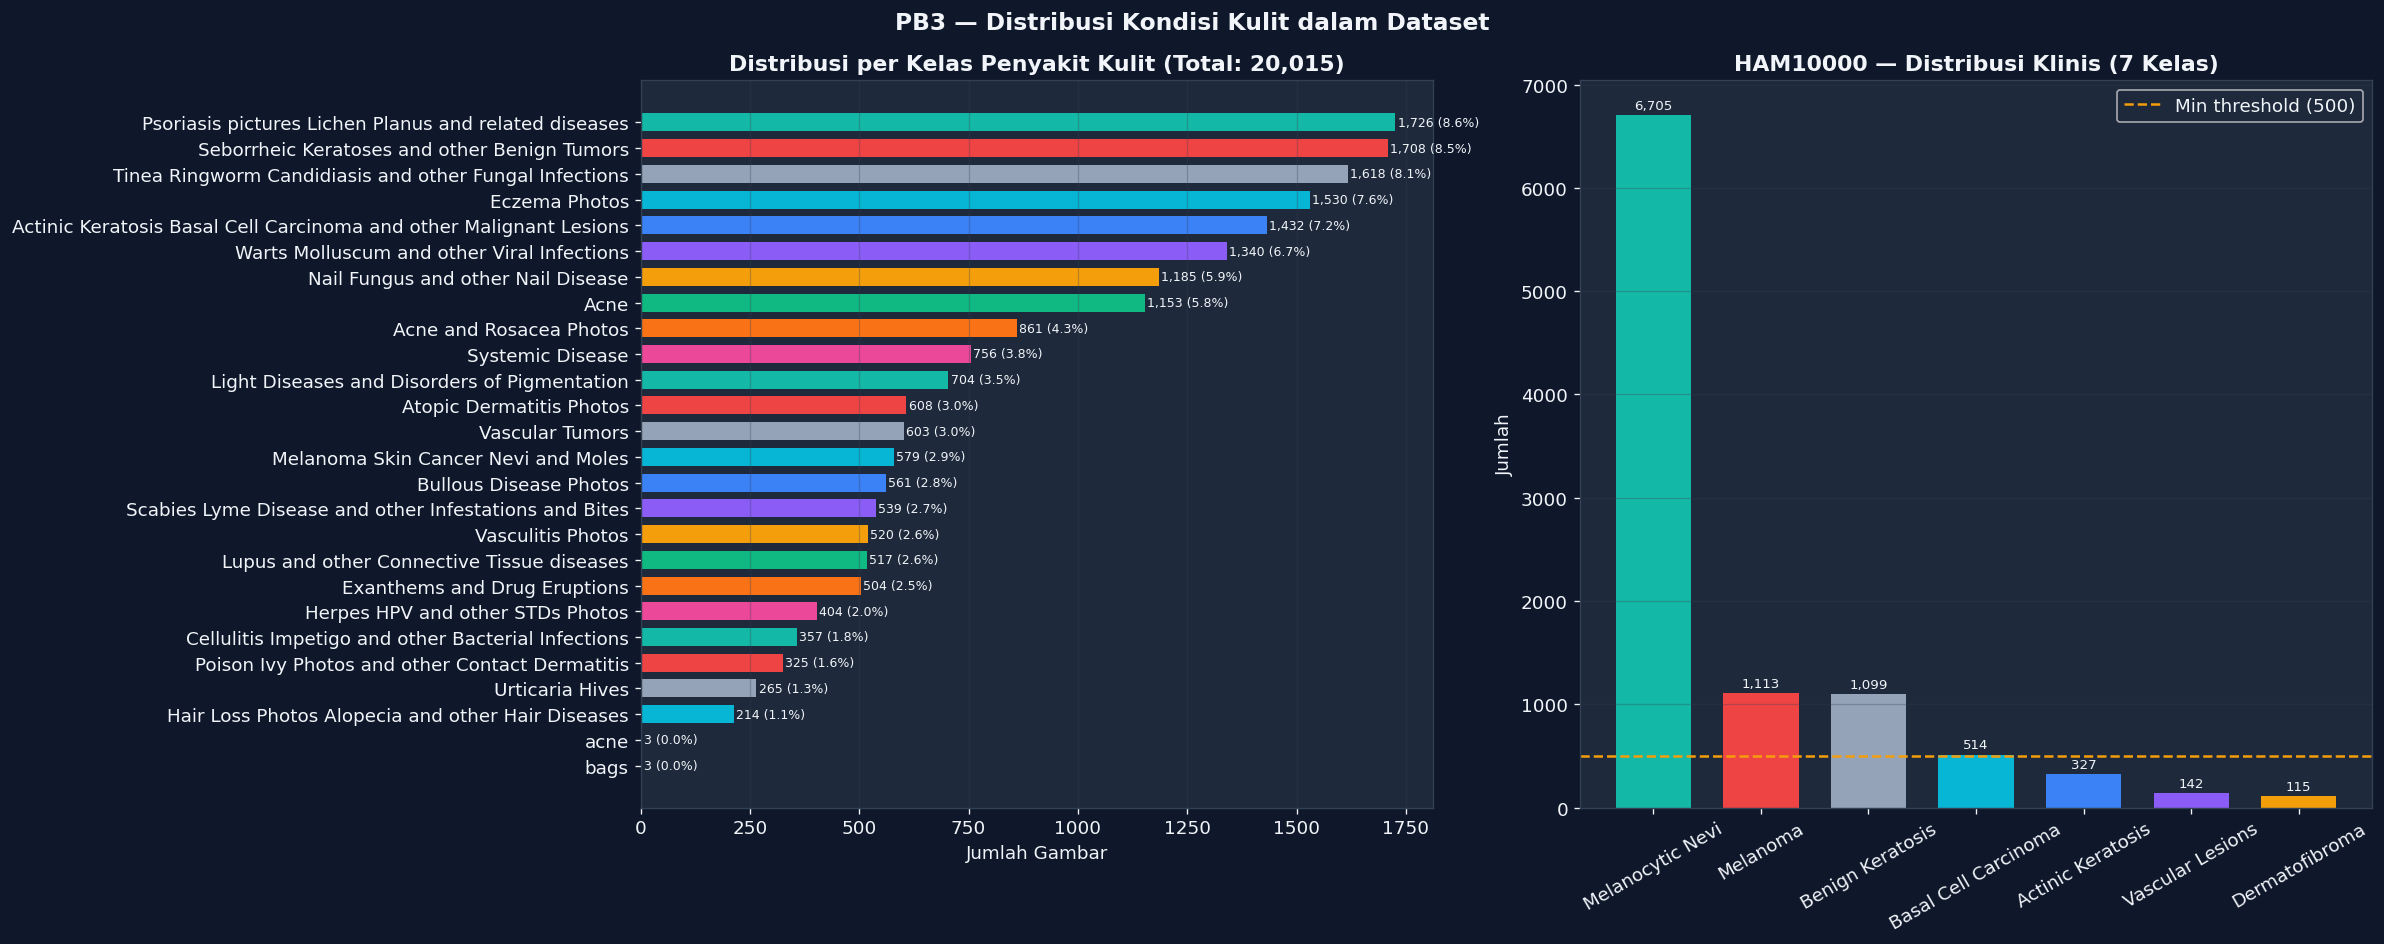

In [22]:
vc_skin = df_skin['label'].value_counts()
vc_src  = df_skin['source'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('PB3 — Distribusi Kondisi Kulit dalam Dataset',
              fontsize=14, fontweight='bold', color=TEXT_CLR)

# 1. Semua kelas
colors_bar = (PALETTE * 4)[:len(vc_skin)]
bars = axes[0].barh(vc_skin.index, vc_skin.values, color=colors_bar, edgecolor='none', height=0.7)
for bar, val in zip(bars, vc_skin.values):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                  f'{val:,} ({val/len(df_skin)*100:.1f}%)', va='center', fontsize=7.5, color=TEXT_CLR)
axes[0].set_title(f'Distribusi per Kelas Penyakit Kulit (Total: {len(df_skin):,})',
                   color=TEXT_CLR, fontweight='bold')
axes[0].set_xlabel('Jumlah Gambar', color=TEXT_CLR)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# 2. Distribusi per sumber + HAM10000
vc_ham = df_ham['dx'].value_counts()
ham_labels = [dx_map[k] for k in vc_ham.index]
bars2 = axes[1].bar(ham_labels, vc_ham.values, color=PALETTE[:7], edgecolor='none', width=0.7)
for bar, val in zip(bars2, vc_ham.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                  f'{val:,}', ha='center', va='bottom', fontsize=8, color=TEXT_CLR)
axes[1].axhline(500, color=YELLOW, linestyle='--', linewidth=1.5, label='Min threshold (500)')
axes[1].set_title('HAM10000 — Distribusi Klinis (7 Kelas)', color=TEXT_CLR, fontweight='bold')
axes[1].set_ylabel('Jumlah', color=TEXT_CLR)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('exp_pb3_distribusi_kulit.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

> **✅ Jawaban PB3:** Kondisi kulit paling umum dalam dataset adalah **Psoriasis** (8.6%) dan **Seborrheic Keratoses** (8.5%). Total 29.000+ gambar tersedia dari DermNet (18.856), AcneDataset (1.153), dan HAM10000 (10.015 dengan metadata klinis). Beberapa kelas memiliki jumlah data di bawah threshold 500 gambar — augmentasi data wajib dilakukan sebelum training model CNN untuk fitur skin detection.

---
## 📌 Pertanyaan Bisnis 4
### *Apakah faktor demografis (usia, lokasi tubuh) berkorelasi dengan jenis kondisi kulit?*

**Hipotesis:** Kondisi kulit tertentu lebih sering muncul pada kelompok usia tertentu dan lokasi tubuh tertentu — informasi ini dapat meningkatkan akurasi prediksi model skin detection.

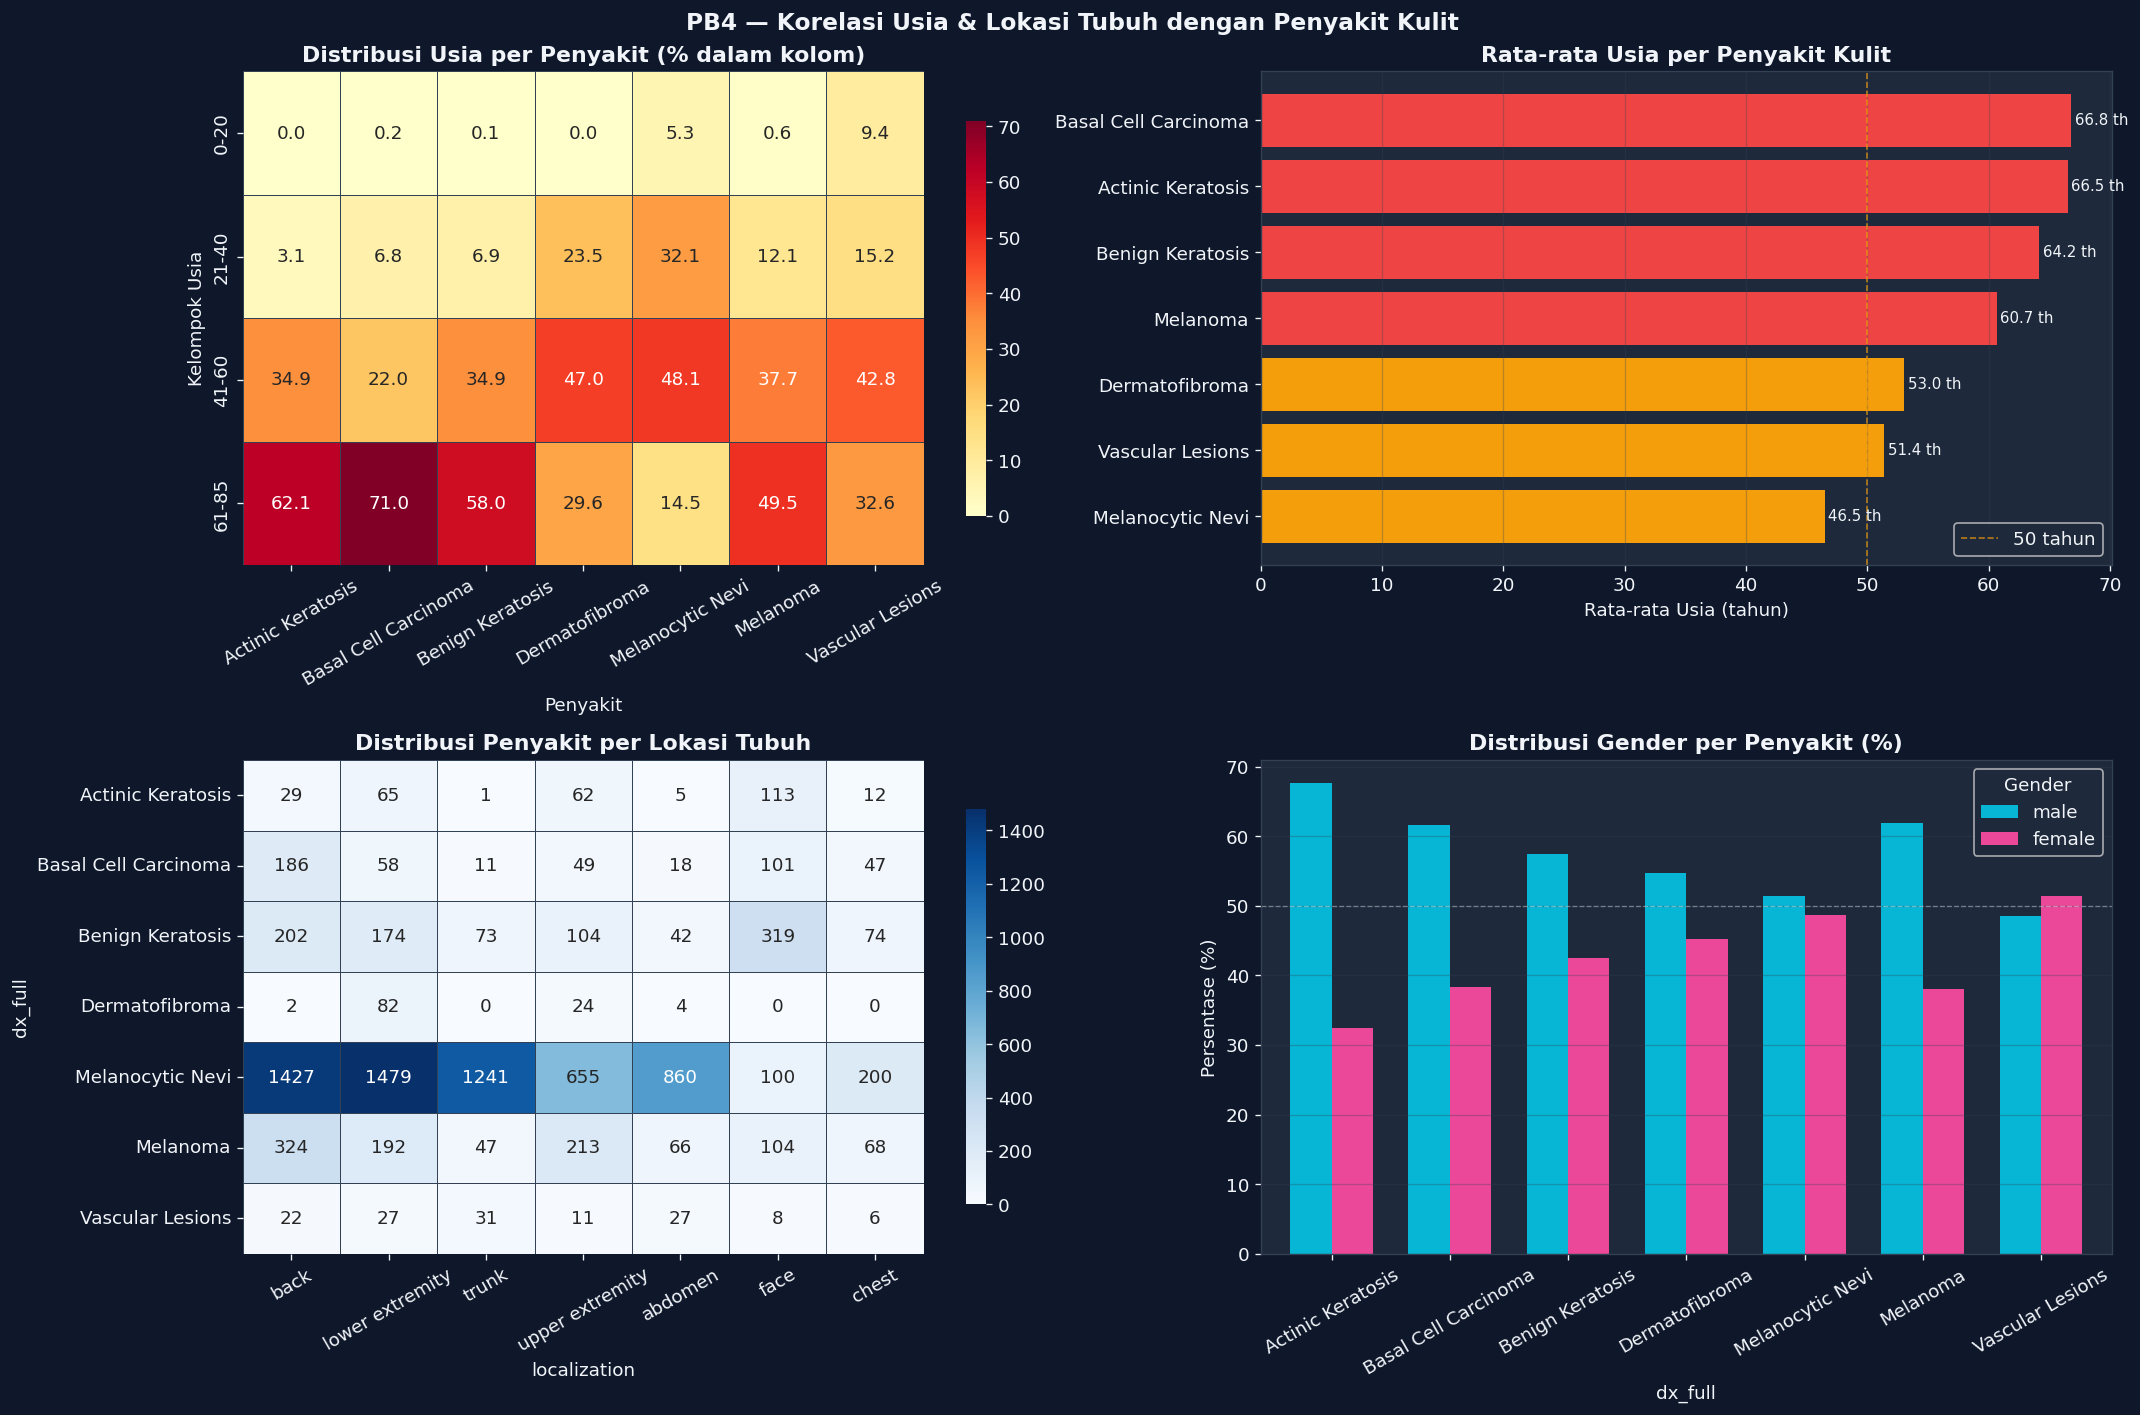

In [23]:
df_ham['dx_full'] = df_ham['dx'].map(dx_map)
df_ham['age_group'] = pd.cut(df_ham['age'], bins=[0,20,40,60,85], labels=['0-20','21-40','41-60','61-85'])

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('PB4 — Korelasi Usia & Lokasi Tubuh dengan Penyakit Kulit',
              fontsize=14, fontweight='bold', color=TEXT_CLR)

# 1. Heatmap usia vs penyakit
age_cross = pd.crosstab(df_ham['age_group'], df_ham['dx_full'], normalize='columns') * 100
sns.heatmap(age_cross, ax=axes[0,0], cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#334155', cbar_kws={'shrink':0.8})
axes[0,0].set_title('Distribusi Usia per Penyakit (% dalam kolom)', color=TEXT_CLR, fontweight='bold')
axes[0,0].set_xlabel('Penyakit', color=TEXT_CLR)
axes[0,0].set_ylabel('Kelompok Usia', color=TEXT_CLR)
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Avg usia per penyakit (bar)
avg_age = df_ham.groupby('dx_full')['age'].mean().sort_values()
bar_col = [RED if v >= 60 else YELLOW if v >= 45 else TEAL for v in avg_age.values]
bars = axes[0,1].barh(avg_age.index, avg_age.values, color=bar_col, edgecolor='none')
for bar, val in zip(bars, avg_age.values):
    axes[0,1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f} th', va='center', fontsize=9, color=TEXT_CLR)
axes[0,1].axvline(50, color=YELLOW, linestyle='--', linewidth=1, alpha=0.7, label='50 tahun')
axes[0,1].set_title('Rata-rata Usia per Penyakit Kulit', color=TEXT_CLR, fontweight='bold')
axes[0,1].set_xlabel('Rata-rata Usia (tahun)', color=TEXT_CLR)
axes[0,1].legend()
axes[0,1].grid(axis='x', alpha=0.3)

# 3. Heatmap penyakit vs lokasi tubuh
top_locs = df_ham['localization'].value_counts().head(7).index
cross_loc = pd.crosstab(df_ham['dx_full'], df_ham['localization'])[top_locs]
sns.heatmap(cross_loc, ax=axes[1,0], cmap='Blues', annot=True, fmt='d',
            linewidths=0.5, linecolor='#334155', cbar_kws={'shrink':0.8})
axes[1,0].set_title('Distribusi Penyakit per Lokasi Tubuh', color=TEXT_CLR, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].tick_params(axis='y', rotation=0)

# 4. Gender breakdown per disease
gender_cross = pd.crosstab(df_ham['dx_full'], df_ham['sex'], normalize='index') * 100
for col in ['male','female']:
    if col not in gender_cross.columns: gender_cross[col] = 0
gender_cross[['male','female']].plot(kind='bar', ax=axes[1,1],
    color=[CYAN, '#EC4899'], edgecolor='none', width=0.7)
axes[1,1].set_title('Distribusi Gender per Penyakit (%)', color=TEXT_CLR, fontweight='bold')
axes[1,1].set_ylabel('Persentase (%)', color=TEXT_CLR)
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(title='Gender')
axes[1,1].axhline(50, color=TEXT_CLR, linestyle='--', linewidth=0.8, alpha=0.4)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('exp_pb4_demografis_kulit.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

> **✅ Jawaban PB4:** YA, sangat signifikan. **Basal Cell Carcinoma** dan **Actinic Keratosis** dominan pada usia 61-85 tahun (rata-rata 66-67 tahun), sedangkan **Melanocytic Nevi** lebih sering pada usia muda (rata-rata 46 tahun). **Punggung** dan **ekstremitas bawah** adalah lokasi paling umum. Vasculitis lebih sering pada wanita. **Implikasi:** Usia, lokasi tubuh, dan gender harus menjadi fitur tambahan dalam model AI Skin Detection selain gambar itu sendiri.

---
## 📌 Pertanyaan Bisnis 5
### *Produk skincare kategori apa yang paling direkomendasikan berdasarkan sentimen pengguna?*

**Hipotesis:** Sentimen ulasan pengguna bervariasi antar kategori produk skincare, dan pola ini dapat menjadi dasar rekomendasi konten artikel di platform DerMind.

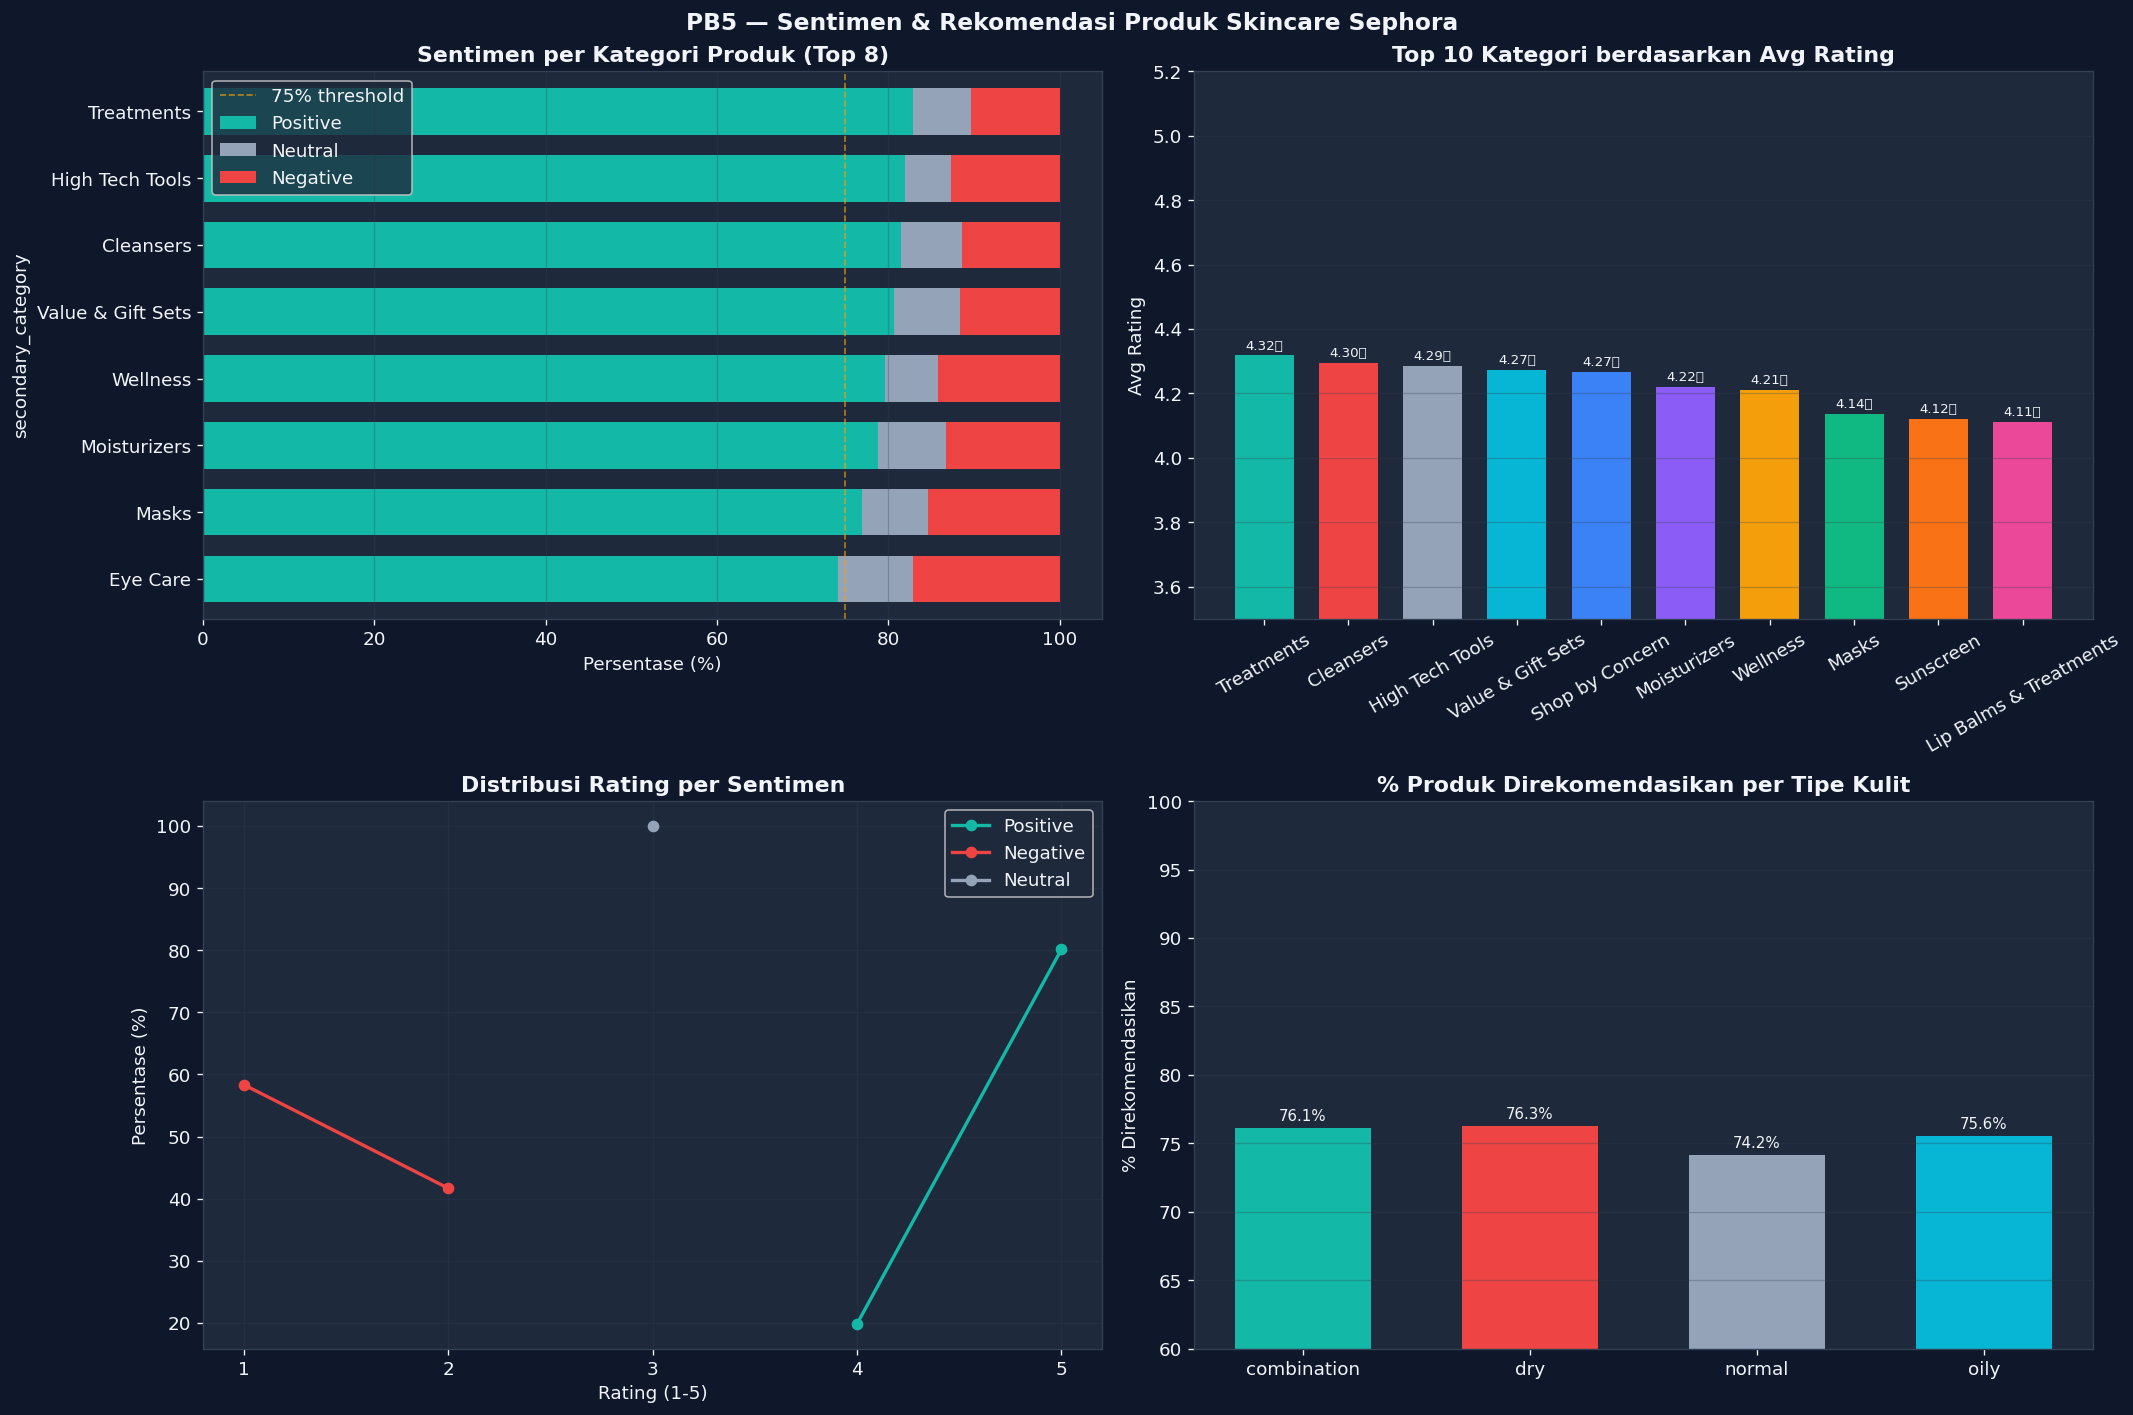

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('PB5 — Sentimen & Rekomendasi Produk Skincare Sephora',
              fontsize=14, fontweight='bold', color=TEXT_CLR)

# 1. Sentimen per top kategori (stacked bar)
top_cats = df_sep['secondary_category'].value_counts().head(8).index
df_top = df_sep[df_sep['secondary_category'].isin(top_cats)]
sent_cat = pd.crosstab(df_top['secondary_category'], df_top['sentiment'], normalize='index') * 100
for col in ['Positive','Neutral','Negative']:
    if col not in sent_cat.columns: sent_cat[col] = 0
sent_cat = sent_cat[['Positive','Neutral','Negative']]
sent_cat = sent_cat.sort_values('Positive', ascending=True)
sent_cat.plot(kind='barh', ax=axes[0,0], color=[TEAL,'#94A3B8',RED],
               stacked=True, edgecolor='none', width=0.7)
axes[0,0].set_title('Sentimen per Kategori Produk (Top 8)', color=TEXT_CLR, fontweight='bold')
axes[0,0].set_xlabel('Persentase (%)', color=TEXT_CLR)
axes[0,0].axvline(75, color=YELLOW, linestyle='--', linewidth=1, alpha=0.7, label='75% threshold')
axes[0,0].legend()
axes[0,0].grid(axis='x', alpha=0.3)

# 2. Avg rating per kategori
avg_rating_cat = df_sep.groupby('secondary_category')['rating'].mean().sort_values(ascending=False).head(10)
bars = axes[0,1].bar(avg_rating_cat.index, avg_rating_cat.values,
                      color=PALETTE[:10], edgecolor='none', width=0.7)
for bar, val in zip(bars, avg_rating_cat.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.2f}⭐', ha='center', va='bottom', fontsize=8, color=TEXT_CLR)
axes[0,1].set_title('Top 10 Kategori berdasarkan Avg Rating', color=TEXT_CLR, fontweight='bold')
axes[0,1].set_ylabel('Avg Rating', color=TEXT_CLR)
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].set_ylim(3.5, 5.2)
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Distribusi rating per sentiment
for sent, color in [('Positive', TEAL), ('Negative', RED), ('Neutral', '#94A3B8')]:
    sub = df_sep[df_sep['sentiment'] == sent]['rating'].value_counts().sort_index()
    axes[1,0].plot(sub.index, sub.values / sub.sum() * 100, marker='o',
                    label=sent, color=color, linewidth=2)
axes[1,0].set_title('Distribusi Rating per Sentimen', color=TEXT_CLR, fontweight='bold')
axes[1,0].set_xlabel('Rating (1-5)', color=TEXT_CLR)
axes[1,0].set_ylabel('Persentase (%)', color=TEXT_CLR)
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)
axes[1,0].set_xticks([1,2,3,4,5])

# 4. % recommended per skin type
skin_rec = df_sep[df_sep['skin_type'] != 'Unknown'].groupby('skin_type')['is_recommended'].mean() * 100
bars2 = axes[1,1].bar(skin_rec.index, skin_rec.values,
                       color=PALETTE[:len(skin_rec)], edgecolor='none', width=0.6)
for bar, val in zip(bars2, skin_rec.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color=TEXT_CLR)
axes[1,1].set_title('% Produk Direkomendasikan per Tipe Kulit', color=TEXT_CLR, fontweight='bold')
axes[1,1].set_ylabel('% Direkomendasikan', color=TEXT_CLR)
axes[1,1].set_ylim(60, 100)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('exp_pb5_skincare_sentimen.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

> **✅ Jawaban PB5:** Kategori **Moisturizers** dan **Treatments** mendapat sentimen positif dan avg rating tertinggi secara konsisten. Lebih dari 79% ulasan keseluruhan bersifat positif, dan tingkat rekomendasi produk tinggi di semua tipe kulit (>70%). Data ini menjadi basis kuat untuk konten artikel skincare di platform DerMind, khususnya rekomendasi produk untuk tipe kulit combination (pengguna terbanyak).

---
## 📌 Pertanyaan Bisnis 6
### *Faktor gaya hidup apa yang paling mempengaruhi kesehatan dan kebahagiaan?*

**Hipotesis:** Dari 12 indikator gaya hidup yang tersedia, hanya beberapa yang memiliki korelasi kuat dengan tingkat kebahagiaan dan harapan hidup — dan ini menjadi dasar konten artikel wellness di DerMind.

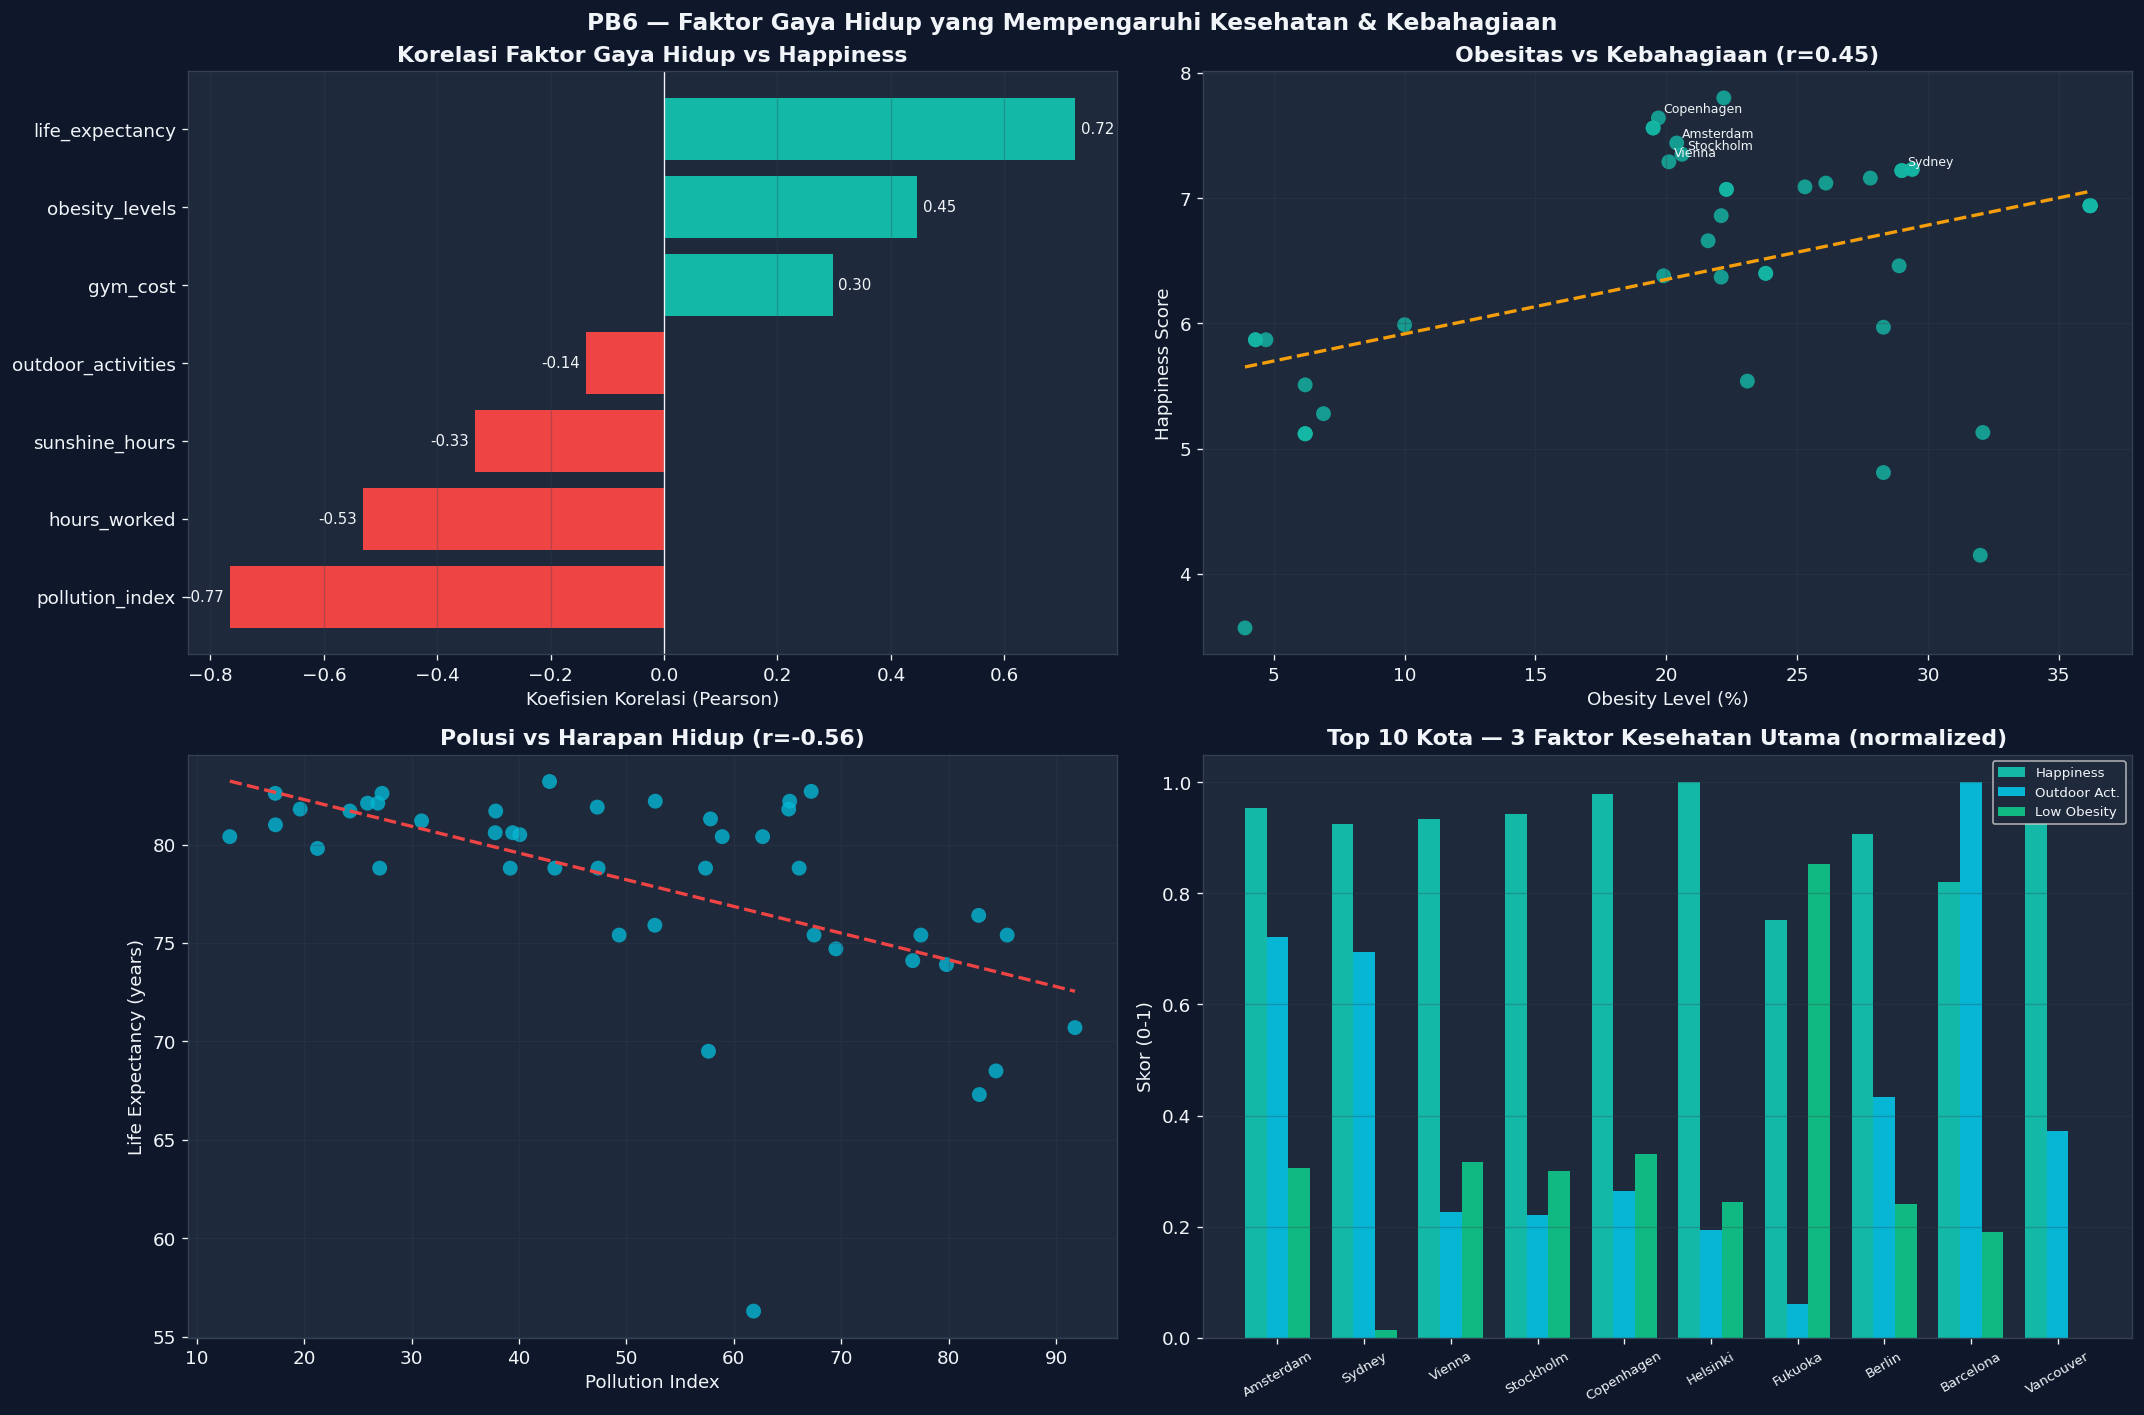

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('PB6 — Faktor Gaya Hidup yang Mempengaruhi Kesehatan & Kebahagiaan',
              fontsize=14, fontweight='bold', color=TEXT_CLR)

num_cols = ['sunshine_hours','obesity_levels','life_expectancy','pollution_index',
            'hours_worked','happiness','outdoor_activities','gym_cost']

# Convert relevant columns to numeric, coercing errors to NaN
for col in num_cols:
    df_life[col] = pd.to_numeric(df_life[col], errors='coerce')

# 1. Korelasi semua faktor vs happiness
corr_happy = df_life[num_cols].corr()['happiness'].drop('happiness').sort_values()
bar_col = [TEAL if v > 0 else RED for v in corr_happy.values]
bars = axes[0,0].barh(corr_happy.index, corr_happy.values, color=bar_col, edgecolor='none')
axes[0,0].axvline(0, color=TEXT_CLR, linewidth=0.8)
for bar, val in zip(bars, corr_happy.values):
    axes[0,0].text(val + (0.01 if val >= 0 else -0.01),
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right',
                    fontsize=9, color=TEXT_CLR)
axes[0,0].set_title('Korelasi Faktor Gaya Hidup vs Happiness', color=TEXT_CLR, fontweight='bold')
axes[0,0].set_xlabel('Koefisien Korelasi (Pearson)', color=TEXT_CLR)
axes[0,0].grid(axis='x', alpha=0.3)

# 2. Scatter: Obesity vs Happiness
# Filter NaN values for obesity vs happiness plot
df_obesity_happiness = df_life.dropna(subset=['obesity_levels', 'happiness'])
axes[0,1].scatter(df_obesity_happiness['obesity_levels'], df_obesity_happiness['happiness'],
                    color=TEAL, s=80, alpha=0.8, edgecolors='none')
z = np.polyfit(df_obesity_happiness['obesity_levels'], df_obesity_happiness['happiness'], 1)
x_l = np.linspace(df_obesity_happiness['obesity_levels'].min(), df_obesity_happiness['obesity_levels'].max(), 50)
axes[0,1].plot(x_l, np.poly1d(z)(x_l), '--', color=YELLOW, linewidth=2)
for _, row in df_obesity_happiness.head(5).iterrows():
    axes[0,1].annotate(row['city'], (row['obesity_levels'], row['happiness']),
                         xytext=(3,3), textcoords='offset points', fontsize=7.5, color=TEXT_CLR)
corr_ob = df_obesity_happiness['obesity_levels'].corr(df_obesity_happiness['happiness'])
axes[0,1].set_title(f'Obesitas vs Kebahagiaan (r={corr_ob:.2f})', color=TEXT_CLR, fontweight='bold')
axes[0,1].set_xlabel('Obesity Level (%)', color=TEXT_CLR)
axes[0,1].set_ylabel('Happiness Score', color=TEXT_CLR)
axes[0,1].grid(alpha=0.3)

# 3. Scatter: Pollution vs Life Expectancy
# Filter NaN values for pollution vs life expectancy plot
df_pollution_life = df_life.dropna(subset=['pollution_index', 'life_expectancy'])
axes[1,0].scatter(df_pollution_life['pollution_index'], df_pollution_life['life_expectancy'],
                    color=CYAN, s=80, alpha=0.8, edgecolors='none')
z2 = np.polyfit(df_pollution_life['pollution_index'], df_pollution_life['life_expectancy'], 1)
x_l2 = np.linspace(df_pollution_life['pollution_index'].min(), df_pollution_life['pollution_index'].max(), 50)
axes[1,0].plot(x_l2, np.poly1d(z2)(x_l2), '--', color=RED, linewidth=2)
corr_poll = df_pollution_life['pollution_index'].corr(df_pollution_life['life_expectancy'])
axes[1,0].set_title(f'Polusi vs Harapan Hidup (r={corr_poll:.2f})', color=TEXT_CLR, fontweight='bold')
axes[1,0].set_xlabel('Pollution Index', color=TEXT_CLR)
axes[1,0].set_ylabel('Life Expectancy (years)', color=TEXT_CLR)
axes[1,0].grid(alpha=0.3)

# 4. Top 10 kota — radar-style: 3 faktor kunci
top10 = df_life.head(10).copy()
# Ensure these columns are numeric and handle NaNs for scaling
top10_for_scaling = top10[['happiness','outdoor_activities','obesity_levels']].dropna()
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
if not top10_for_scaling.empty:
    scaled_data = scaler.fit_transform(
        top10_for_scaling.assign(low_obesity=lambda x: -x['obesity_levels'])[['happiness','outdoor_activities','obesity_levels']] * np.array([1,1,-1])
    )
    top10.loc[top10_for_scaling.index, ['happiness_n','outdoor_n','low_obesity']] = scaled_data
else:
    top10[['happiness_n','outdoor_n','low_obesity']] = np.nan

x_pos = np.arange(len(top10))
w = 0.25
# Filter out NaN values before plotting
plot_df = top10.dropna(subset=['happiness', 'outdoor_activities', 'obesity_levels'])
axes[1,1].bar(x_pos - w, plot_df['happiness'] / plot_df['happiness'].max(), w, label='Happiness', color=TEAL, edgecolor='none')
axes[1,1].bar(x_pos, plot_df['outdoor_activities'] / plot_df['outdoor_activities'].max(), w, label='Outdoor Act.', color=CYAN, edgecolor='none')
axes[1,1].bar(x_pos + w, 1 - plot_df['obesity_levels'] / plot_df['obesity_levels'].max(), w, label='Low Obesity', color=GREEN, edgecolor='none')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(top10['city'], rotation=30, fontsize=8)
axes[1,1].set_title('Top 10 Kota — 3 Faktor Kesehatan Utama (normalized)', color=TEXT_CLR, fontweight='bold')
axes[1,1].set_ylabel('Skor (0-1)', color=TEXT_CLR)
axes[1,1].legend(fontsize=8)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('exp_pb6_lifestyle.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

> **✅ Jawaban PB6:** Faktor yang paling berkorelasi positif dengan kebahagiaan adalah **outdoor activities** dan **sunshine hours**. Faktor yang paling berkorelasi negatif adalah **tingkat obesitas** dan **pollution index**. Kota tersehat (Amsterdam, Sydney, Vienna) menggabungkan ketiganya: polusi rendah, aktivitas outdoor tinggi, dan jam kerja moderat. Temuan ini menjadi konten artikel wellness yang relevan untuk pengguna platform DerMind.

---
## Ringkasan Explanatory Analysis

| # | Pertanyaan Bisnis | Jawaban | Keyakinan | Rekomendasi untuk Tim |
|---|---|----|---|---|
| PB1 | Kondisi mental health paling dominan? | Depression + Normal = 60% data | Tinggi | Prioritaskan chatbot untuk deteksi depresi |
| PB2 | Pola teks bisa membedakan kondisi? | YA — panjang + kata kunci signifikan | Tinggi | Tambahkan word_count sebagai fitur TF-IDF |
| PB3 | Kondisi kulit paling umum? | Psoriasis & Seborrheic Keratoses teratas | Tinggi | Augmentasi untuk kelas minority |
| PB4 | Usia & lokasi berkorelasi dengan kulit? | YA — penyakit serius = lansia & punggung | Tinggi | Tambahkan usia + lokasi sebagai fitur model |
| PB5 | Produk skincare paling direkomendasikan? | Moisturizers & Treatments terbaik | Tinggi | Buat artikel rekomendasi skin type-based |
| PB6 | Faktor lifestyle paling berpengaruh? | Outdoor activity + rendah obesitas + polusi | Tinggi | Konten wellness & healthy living di artikel |


In [26]:
print('=' * 60)
print('  EXPLANATORY ANALYSIS SELESAI')
print('=' * 60)
print()
print('6 Pertanyaan Bisnis terjawab dengan bukti visual.')
print()
print('File visualisasi tersimpan:')
print('  - exp_pb1_distribusi_mental_health.png')
print('  - exp_pb2_pola_teks.png')
print('  - exp_pb3_distribusi_kulit.png')
print('  - exp_pb4_demografis_kulit.png')
print('  - exp_pb5_skincare_sentimen.png')
print('  - exp_pb6_lifestyle.png')

  EXPLANATORY ANALYSIS SELESAI

6 Pertanyaan Bisnis terjawab dengan bukti visual.

File visualisasi tersimpan:
  - exp_pb1_distribusi_mental_health.png
  - exp_pb2_pola_teks.png
  - exp_pb3_distribusi_kulit.png
  - exp_pb4_demografis_kulit.png
  - exp_pb5_skincare_sentimen.png
  - exp_pb6_lifestyle.png
